In [11]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cebra.datasets
from cebra import CEBRA
import glob
import pickle


In [224]:
with open("lorenz_latent_embeddings_orig.pkl", "rb") as f:
    emb_dict = pickle.load(f)

run_names = sorted(emb_dict.keys())

In [234]:
run_names_without_true = run_names[:9]
run_names_without_true

['0true',
 'lorenz_exp0_seed123',
 'lorenz_exp10_seed133',
 'lorenz_exp11_seed134',
 'lorenz_exp12_seed135',
 'lorenz_exp13_seed136',
 'lorenz_exp14_seed137',
 'lorenz_exp15_seed138',
 'lorenz_exp1_seed124']

In [235]:
#run_names = run_names[1:]
#run_names = ['lorenz_exp0_epoch2101+501_noise0.001_seed140',
#             'lorenz_exp1_epoch2101+501_noise0.001_seed141',
#             'lorenz_exp2_epoch2101+501_noise0.001_seed142']
#for_run = run_names
for_run = run_names_without_true
embeddings = [emb_dict[name] for name in for_run]
for_run

['0true',
 'lorenz_exp0_seed123',
 'lorenz_exp10_seed133',
 'lorenz_exp11_seed134',
 'lorenz_exp12_seed135',
 'lorenz_exp13_seed136',
 'lorenz_exp14_seed137',
 'lorenz_exp15_seed138',
 'lorenz_exp1_seed124']

In [98]:
alma = np.flip(run_names).tolist()

In [236]:
scores, pairs, subjects = cebra.sklearn.metrics.consistency_score(
    embeddings=embeddings,
    between="runs")


In [230]:
scores.shape

(240,)

In [231]:
pairs.shape

(240, 2)

In [228]:
np.mean(scores)

np.float64(0.9988554614285629)

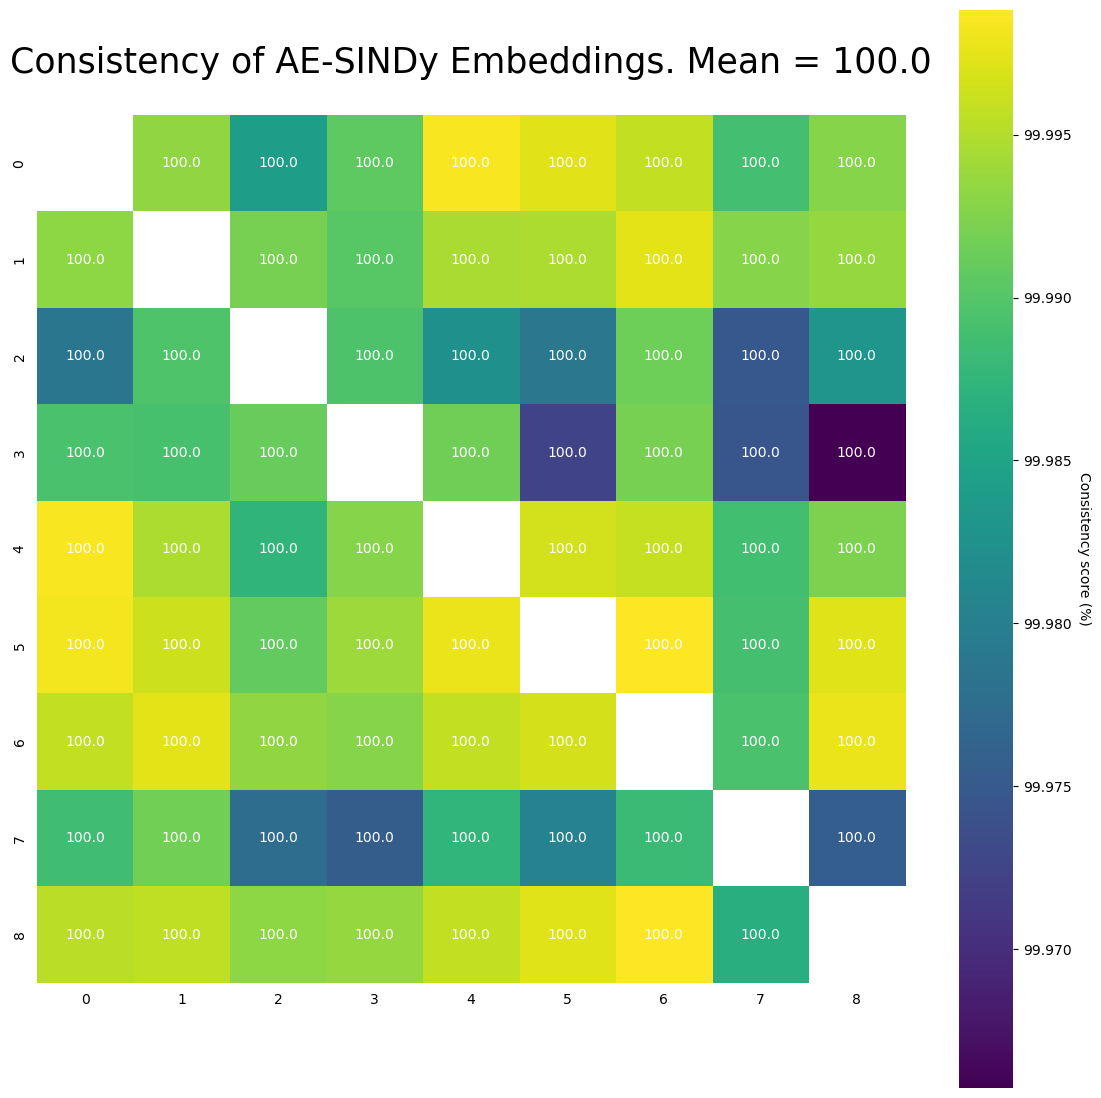

In [238]:
fig = plt.figure(figsize=(14, 14))
ax = plt.gca()
cebra.plot_consistency(scores, pairs=pairs, datasets=subjects, ax=ax, cmap='viridis', dpi=600)
ax.set_title(f'Consistency of AE-SINDy Embeddings. Mean = {np.mean(scores)*100:.1f}', fontsize=25, pad=30)
plt.show()
#fig.savefig('pics/consistency_without_true.png', dpi=600)


In [209]:
nums = [73.9, 71.2, 65.9, 67.4, 76.1, 64.9, 69.2, 72.9]
np.mean(nums)

np.float64(70.1875)

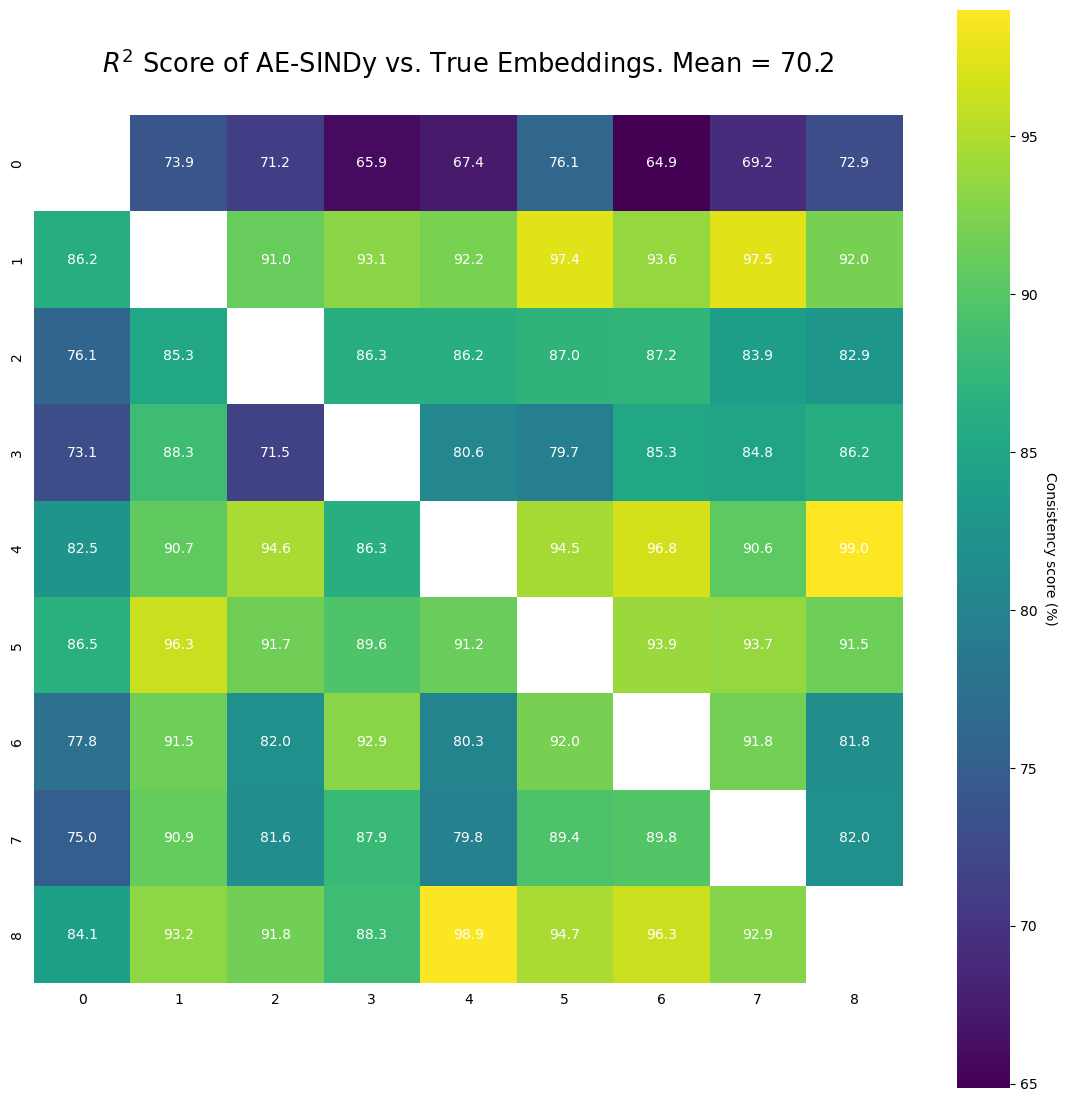

In [219]:
pairs_T = pairs[:, ::-1]   # (i, j) -> (j, i)

fig = plt.figure(figsize=(14, 14))
ax = plt.gca()
cebra.plot_consistency(scores, pairs=pairs_T, datasets=subjects, ax=ax, cmap='viridis', dpi=600)
ax.set_title(r'$R^{2}$ Score of AE-SINDy vs. True Embeddings. Mean = 70.2', fontsize=18.5, pad=30)
plt.show()
fig.savefig('pics/consistency_with_true.png', dpi=600)


In [78]:
from scipy.linalg import orthogonal_procrustes
import numpy as np

A = embeddings[0] - embeddings[0].mean(0)
for k in range(1, len(embeddings)):
    B = embeddings[k] - embeddings[k].mean(0)
    R, _ = orthogonal_procrustes(B, A)   # find rotation mapping B->A
    B_aligned = B @ R
    mse = np.mean((A - B_aligned)**2)
    print(k, "Procrustes MSE:", mse)


1 Procrustes MSE: 5.616355
2 Procrustes MSE: 8.877685
3 Procrustes MSE: 4.079003
4 Procrustes MSE: 10.073659
5 Procrustes MSE: 4.7388196
6 Procrustes MSE: 3.4453223
7 Procrustes MSE: 5.5706105
8 Procrustes MSE: 9.672131


In [79]:
import numpy as np
from scipy.linalg import orthogonal_procrustes

ref_name = '0true'
Z_ref = emb_dict[ref_name]


In [80]:
def align_to_reference(Z, Z_ref):
    # center both (remove mean)
    Zc = Z - Z.mean(axis=0, keepdims=True)
    Rc = Z_ref - Z_ref.mean(axis=0, keepdims=True)

    # find best orthogonal map: Zc @ R ≈ Rc
    R, _ = orthogonal_procrustes(Zc, Rc)
    Z_aligned = Zc @ R

    # optionally put back the reference mean (so everything sits in same place)
    Z_aligned = Z_aligned + Z_ref.mean(axis=0, keepdims=True)
    return Z_aligned, R


In [81]:
aligned = {}
rotations = {}

for name in run_names:
    Z = emb_dict[name]
    Z_aligned, R = align_to_reference(Z, Z_ref)
    aligned[name] = Z_aligned
    rotations[name] = R


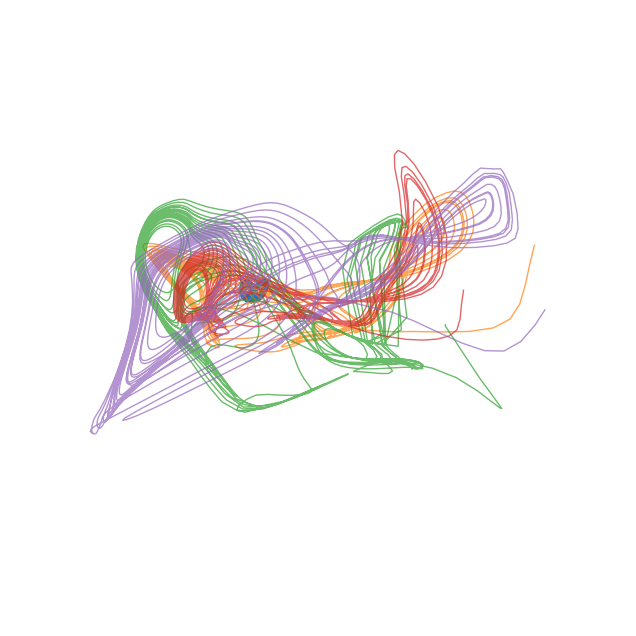

In [82]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(aligned[ref_name][:,0], aligned[ref_name][:,1], aligned[ref_name][:,2], linewidth=3)

for name in run_names[1:5]:
    Z = aligned[name]
    ax.plot(Z[:,0], Z[:,1], Z[:,2], linewidth=1, alpha=0.7)

ax.axis('off')
ax.view_init(azim=120)
plt.show()


In [83]:
for name in run_names:
    err = np.mean((emb_dict[name] - Z_ref)**2)
    print(name, "MSE to ref:", err)


0true MSE to ref: 0.0
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed145 MSE to ref: 25.157913
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed146 MSE to ref: 29.462978
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed147 MSE to ref: 13.7582035
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed148 MSE to ref: 40.051537
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed149 MSE to ref: 29.50536
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed150 MSE to ref: 17.321266
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed151 MSE to ref: 61.22206
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed152 MSE to ref: 31.05613


In [200]:
for name in run_names:
    err = np.mean((aligned[name] - Z_ref)**2)
    print(name, "MSE to ref:", err)


0true MSE to ref: 0.0
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed145 MSE to ref: 0.011361845
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed146 MSE to ref: 0.012499607
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed147 MSE to ref: 0.015130771
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed148 MSE to ref: 0.014487361
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed149 MSE to ref: 0.01051772


KeyError: 'lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed150'

In [202]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

ref_name = run_names[0]          # choose reference
Z_ref = emb_dict[ref_name]       # shape (N, 3)

aligned = {ref_name: Z_ref}
align_models = {ref_name: None}
align_r2 = {ref_name: 1.0}

for name in run_names[1:]:
    Z = emb_dict[name]

    lm = LinearRegression(fit_intercept=True)
    lm.fit(X=Z, y=Z_ref)                 # learn affine map: Z -> Z_ref
    Z_aligned = lm.predict(Z)            # aligned version of this run

    aligned[name] = Z_aligned
    align_models[name] = lm
    align_r2[name] = r2_score(Z_ref, Z_aligned, multioutput='uniform_average')

# quick check
print(f'{ref_name} is the reference\n------------------------------------')
for name in run_names:
    print(name, "R2-to-ref:", align_r2[name])


0true is the reference
------------------------------------
0true R2-to-ref: 1.0
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed145 R2-to-ref: 0.7390753626823425
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed146 R2-to-ref: 0.7124946117401123
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed147 R2-to-ref: 0.658639132976532
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed148 R2-to-ref: 0.6735183596611023
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed149 R2-to-ref: 0.7613332271575928
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed150 R2-to-ref: 0.6486623883247375
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed151 R2-to-ref: 0.6922557950019836
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed152 R2-to-ref: 0.7287060618400574


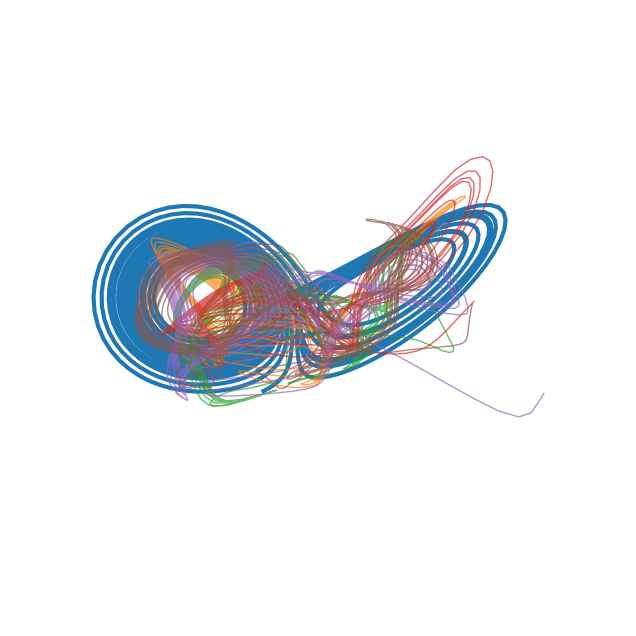

In [87]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# plot reference thick
Z0 = aligned[ref_name]
ax.plot(Z0[:,0], Z0[:,1], Z0[:,2], linewidth=3)

# overlay a few other runs
for name in run_names[1:6]:
    Z = aligned[name]
    ax.plot(Z[:,0], Z[:,1], Z[:,2], linewidth=1, alpha=0.7)

ax.axis('off')
ax.view_init(azim=120)
plt.show()


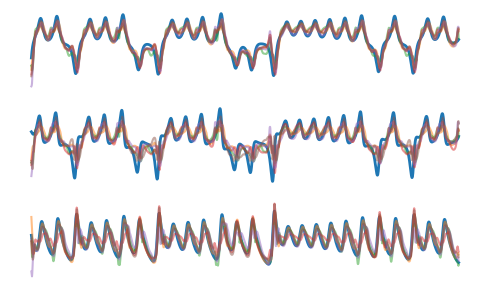

In [88]:
t_plot = np.arange(Z_ref.shape[0])  # replace with your real t if saved

plt.figure(figsize=(5,3))
for i in range(3):
    plt.subplot(3,1,i+1)
    plt.plot(t_plot, aligned[ref_name][:,i], linewidth=2)
    for name in run_names[1:6]:
        plt.plot(t_plot, aligned[name][:,i], alpha=0.5)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [89]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# choose a reference run and a few runs to display
ref_name = run_names[0]
show_names = [ref_name] + run_names[1:]   # show 6 total (change as you like)

Z_ref = emb_dict[ref_name]

aligned = {ref_name: Z_ref}
r2_to_ref = {ref_name: 1.0}

for name in show_names:
    if name == ref_name:
        continue
    Z = emb_dict[name]
    lm = LinearRegression(fit_intercept=True)
    lm.fit(Z, Z_ref)            # map this run -> reference coordinate system
    aligned[name] = lm.predict(Z)
    r2_to_ref[name] = r2_score(Z_ref, aligned[name], multioutput='uniform_average')

print(f"R2 to reference to {ref_name}:")
for name in show_names:
    print(name, r2_to_ref[name])


R2 to reference to 0true:
0true 1.0
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed145 0.7390753626823425
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed146 0.7124946117401123
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed147 0.658639132976532
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed148 0.6735183596611023
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed149 0.7613332271575928
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed150 0.6486623883247375
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed151 0.6922557950019836
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed152 0.7287060618400574


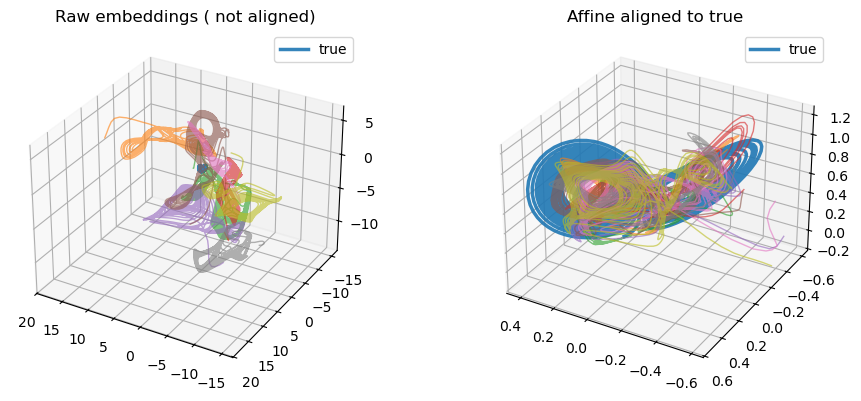

In [90]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 4))

ax_raw = fig.add_subplot(1, 2, 1, projection='3d')
ax_aln = fig.add_subplot(1, 2, 2, projection='3d')

# --- RAW ---
for name in show_names:
    Z = emb_dict[name]
    if name == ref_name:
        ax_raw.plot(Z[:,0], Z[:,1], Z[:,2], linewidth=2.5, alpha=0.9, label='true')
    else:
        ax_raw.plot(Z[:,0], Z[:,1], Z[:,2], linewidth=1, alpha=0.6)
ax_raw.set_title("Raw embeddings ( not aligned)")
#ax_raw.axis('off')
ax_raw.view_init(azim=120)
ax_raw.legend()

# --- ALIGNED ---
for name in show_names:
    Z = aligned[name]
    if name == ref_name:
        ax_aln.plot(Z[:,0], Z[:,1], Z[:,2], linewidth=2.5, alpha=0.9, label='true')
    else:
        ax_aln.plot(Z[:,0], Z[:,1], Z[:,2], linewidth=1, alpha=0.6)
ax_aln.set_title(f"Affine aligned to true")
#ax_aln.axis('off')
ax_aln.view_init(azim=120)
ax_aln.legend()

plt.tight_layout()
plt.show()


In [91]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# choose a reference run and a few runs to display
ref_name = run_names[0]
show_names = [ref_name] + run_names[1:]   # show 6 total (change as you like)

Z_ref = emb_dict[ref_name]

aligned = {ref_name: Z_ref}
r2_to_ref = {ref_name: 1.0}

for name in show_names:
    if name == ref_name:
        continue
    Z = emb_dict[name]
    lm = LinearRegression(fit_intercept=True)
    lm.fit(Z, Z_ref)            # map this run -> reference coordinate system
    aligned[name] = lm.predict(Z)
    r2_to_ref[name] = r2_score(Z_ref, aligned[name], multioutput='uniform_average')

print(f"R2 to reference to {ref_name}:")
for name in show_names:
    print(name, r2_to_ref[name])


R2 to reference to 0true:
0true 1.0
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed145 0.7390753626823425
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed146 0.7124946117401123
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed147 0.658639132976532
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed148 0.6735183596611023
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed149 0.7613332271575928
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed150 0.6486623883247375
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed151 0.6922557950019836
lorenz_mlp_nonlin_mixer_001step_epoch2101+501_noise0.001_seed152 0.7287060618400574


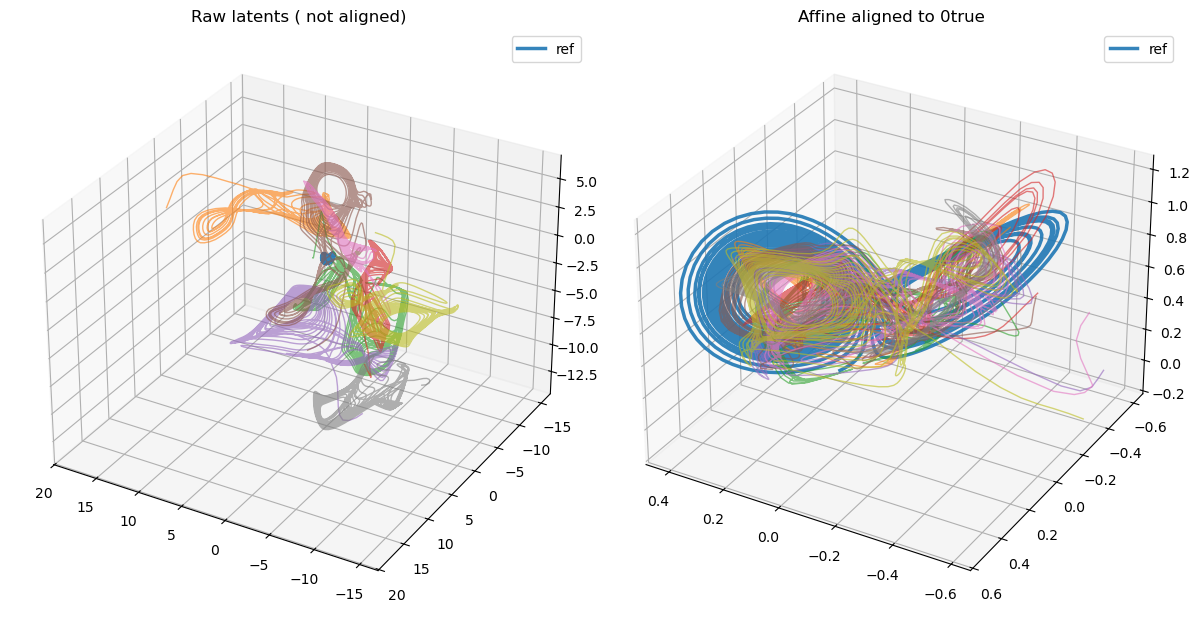

In [92]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))

ax_raw = fig.add_subplot(1, 2, 1, projection='3d')
ax_aln = fig.add_subplot(1, 2, 2, projection='3d')

# --- RAW ---
for name in show_names:
    Z = emb_dict[name]
    if name == ref_name:
        ax_raw.plot(Z[:,0], Z[:,1], Z[:,2], linewidth=2.5, alpha=0.9, label='ref')
    else:
        ax_raw.plot(Z[:,0], Z[:,1], Z[:,2], linewidth=1, alpha=0.6)
ax_raw.set_title("Raw latents ( not aligned)")
#ax_raw.axis('off')
ax_raw.view_init(azim=120)
ax_raw.legend()

# --- ALIGNED ---
for name in show_names:
    Z = aligned[name]
    if name == ref_name:
        ax_aln.plot(Z[:,0], Z[:,1], Z[:,2], linewidth=2.5, alpha=0.9, label='ref')
    else:
        ax_aln.plot(Z[:,0], Z[:,1], Z[:,2], linewidth=1, alpha=0.6)
ax_aln.set_title(f"Affine aligned to {ref_name}")
#ax_aln.axis('off')
ax_aln.view_init(azim=120)
ax_aln.legend()

plt.tight_layout()
plt.show()


In [197]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


def affine_align(Z_src, Z_tgt):
    """
    Fit affine map Z_src -> Z_tgt and return aligned Z and R^2.
    """
    lm = LinearRegression(fit_intercept=True)
    lm.fit(Z_src, Z_tgt)
    Z_aligned = lm.predict(Z_src)
    r2 = r2_score(Z_tgt, Z_aligned, multioutput="uniform_average")
    return Z_aligned, r2


def plot_raw_and_aligned_embeddings(
    emb_dict,
    ref_name=None,
    show_names=None,
    azim=120,
    elev=None,
    figsize=(10, 6),
    title_raw="Raw embeddings (not aligned)",
    title_aln="Affine aligned to reference",
    label_ref="true",
    lw_ref=2.5,
    lw_other=1.0,
    alpha_ref=0.9,
    alpha_other=0.6,
    legend_fontsize=9,
):
    """
    Make TWO separate 3D plots:
      1) raw embeddings
      2) embeddings affine-aligned to a reference, with R^2 shown in legend

    Args:
      emb_dict: dict[str -> np.ndarray], each value shape (N, 3)
      ref_name: key in emb_dict to align everything to (default: first key in sorted order)
      show_names: list of keys to plot (default: all keys sorted)
      azim/elev: passed to ax.view_init
    """
    if not emb_dict:
        raise ValueError("emb_dict is empty.")

    # pick reference
    if ref_name is None:
        ref_name = sorted(emb_dict.keys())[0]
    if ref_name not in emb_dict:
        raise KeyError(f"ref_name='{ref_name}' not in emb_dict keys.")

    # choose what to show
    if show_names is None:
        show_names = sorted(emb_dict.keys())
    else:
        # keep only those present
        show_names = [k for k in show_names if k in emb_dict]
        if ref_name not in show_names:
            show_names = [ref_name] + show_names

    # sanity checks
    Z_ref = emb_dict[ref_name]
    if Z_ref.ndim != 2 or Z_ref.shape[1] != 3:
        raise ValueError(f"Reference embedding must be (N,3). Got {Z_ref.shape}.")
    N = Z_ref.shape[0]
    for k in show_names:
        Z = emb_dict[k]
        if Z.shape != (N, 3):
            raise ValueError(
                f"All embeddings must have identical shape (N,3). "
                f"Key '{k}' has {Z.shape}, reference has {(N,3)}."
            )

    # compute aligned + R^2
    aligned = {ref_name: Z_ref}
    r2s = {ref_name: 1.0}
    for k in show_names:
        if k == ref_name:
            continue
        aligned[k], r2s[k] = affine_align(emb_dict[k], Z_ref)

    # ---------- FIG 1: RAW ----------
    fig_raw = plt.figure(figsize=figsize)
    ax_raw = fig_raw.add_subplot(111, projection="3d")

    for k in show_names:
        Z = emb_dict[k]
        if k == ref_name:
            ax_raw.plot(
                Z[:, 0], Z[:, 1], Z[:, 2],
                linewidth=lw_ref, alpha=alpha_ref, label=label_ref
            )
        else:
            ax_raw.plot(
                Z[:, 0], Z[:, 1], Z[:, 2],
                linewidth=lw_other, alpha=alpha_other
            )

    ax_raw.set_title(title_raw)
    if elev is None:
        ax_raw.view_init(azim=azim)
    else:
        ax_raw.view_init(elev=elev, azim=azim)
    ax_raw.legend(fontsize=legend_fontsize)
    plt.tight_layout()
    plt.show()

    # ---------- FIG 2: ALIGNED ----------
    fig_aln = plt.figure(figsize=figsize)
    ax_aln = fig_aln.add_subplot(111, projection="3d")

    for k in show_names:
        Z = aligned[k]
        if k == ref_name:
            ax_aln.plot(
                Z[:, 0], Z[:, 1], Z[:, 2],
                linewidth=lw_ref, alpha=alpha_ref, label=label_ref
            )
        else:
            ax_aln.plot(
                Z[:, 0], Z[:, 1], Z[:, 2],
                linewidth=lw_other, alpha=alpha_other,
                label=f"{k}  (R$^2$={r2s[k]:.3f})"
            )

    ax_aln.set_title(f"{title_aln}: {ref_name}")
    if elev is None:
        ax_aln.view_init(azim=azim)
    else:
        ax_aln.view_init(elev=elev, azim=azim)
    ax_aln.legend(fontsize=legend_fontsize)
    plt.tight_layout()
    plt.show()

    return aligned, r2s


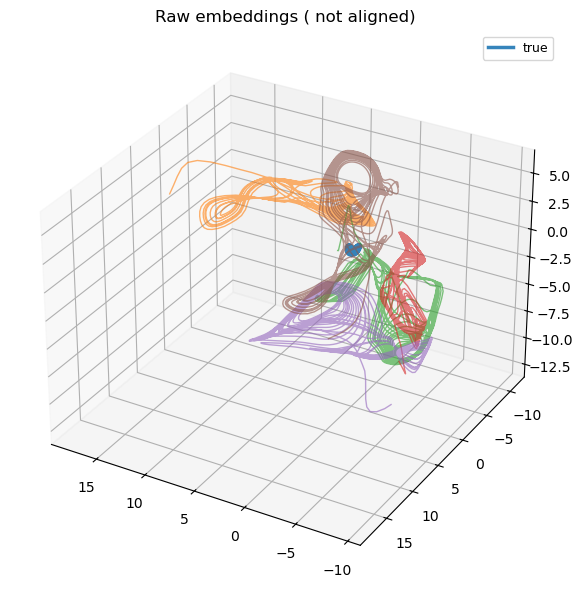

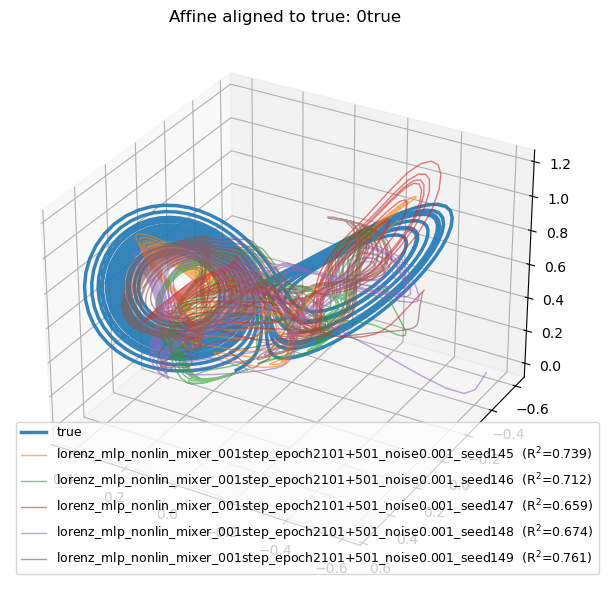

In [199]:
# emb_dict: dict of AE-SINDy embeddings, each (N,3)
# run_names = sorted(emb_dict.keys())
ref_name = run_names[0]                 # e.g. your "true" run (or whatever you want as reference)
show_names = run_names[:6]              # plot first 6 (adjust)

aligned, r2s = plot_raw_and_aligned_embeddings(
    emb_dict,
    ref_name=ref_name,
    show_names=show_names,
    title_raw="Raw embeddings ( not aligned)",
    title_aln="Affine aligned to true"
)
